# Tracking of several entities using Trackpy

# Importations

In [1]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience

import pims
import trackpy as tp

import cv2

from tqdm import tqdm
import os
import shutil

import sys

In [2]:
# Check python version 
# Should be the one installed: python 3.9
print(sys.version)
# Check which executable 
print()
print(sys.executable)
# And what is in the path
print()
print(sys.path)

3.14.4 | packaged by conda-forge | (main, Apr  8 2026, 01:59:35) [GCC 14.3.0]

/home/nfares/miniforge3/envs/trackpy/bin/python

['/home/nfares/miniforge3/envs/trackpy/lib/python314.zip', '/home/nfares/miniforge3/envs/trackpy/lib/python3.14', '/home/nfares/miniforge3/envs/trackpy/lib/python3.14/lib-dynload', '', '/home/nfares/miniforge3/envs/trackpy/lib/python3.14/site-packages']


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
mpl.rc('figure',  figsize=(10, 5))
mpl.rc('image', cmap='gray')
mpl.rc('text', usetex=True)

# Auxiliary functions

In [4]:
def normalize8(I):
    mn = I.min()
    mx = I.max()
    I = ((I - mn) / (mx - mn)) * 255
    return I.astype(np.uint8)

# Inputs

In [342]:
# Where to find the data
# path2vid = '/mnt/share/nfares/group/palacgrp/Nicolas/20260506_coreshell_diffusion/chamber3_water/nofield.mp4'
path2vid = '../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/ole011_fps_50_p3_no_shell.tif'

# If needed: terminal command to mount the server drives
# sudo mount -t cifs //fs.ista.ac.at/drives/ /mnt/share -o credentials=/etc/smb-credentials,vers=3.0,iocharset=utf8

# Frame rate
fps = 50

# Pixel size (in m)
px = 40e-9

# Get the frames 

In [343]:
@pims.pipeline
def gray(image, channel=2):
    return image[:, :, channel]  # Take just one channel
    # return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# frames = gray(pims.open(path2vid))
# frames = pims.open(path2vid)

# PyAV-based reading

import tifffile

with tifffile.TiffFile(path2vid) as tif:
    # Read all pages directly, bypassing OME metadata
    frames = np.array([page.asarray() for page in tif.pages])

print(frames.shape)  # Should be (101, H, W) or (101, H, W, C)

(501, 328, 426)


In [344]:
frames

array([[[1027,  965, 1032, ..., 1020, 1029, 1045],
        [1088,  993, 1125, ..., 1020, 1060,  978],
        [1040, 1079, 1041, ..., 1044, 1105,  973],
        ...,
        [1100, 1007, 1055, ..., 1007, 1001, 1051],
        [1137, 1173, 1196, ..., 1083, 1185, 1039],
        [1053, 1069, 1090, ..., 1045, 1072, 1016]],

       [[1114,  996, 1078, ..., 1022,  982,  943],
        [1039, 1064, 1107, ..., 1017,  950, 1070],
        [1107, 1112, 1016, ..., 1008, 1054, 1098],
        ...,
        [1096, 1148, 1055, ...,  967, 1098, 1071],
        [1158, 1070, 1096, ..., 1060, 1044, 1137],
        [ 992, 1034, 1091, ..., 1063, 1074, 1049]],

       [[ 987, 1035, 1039, ..., 1000,  968,  925],
        [1069, 1013, 1118, ..., 1059, 1061, 1002],
        [1051, 1174, 1051, ..., 1062, 1065,  990],
        ...,
        [1114, 1032, 1093, ..., 1137, 1082, 1017],
        [1019, 1075, 1133, ..., 1040, 1034, 1034],
        [1096, 1082, 1163, ..., 1021, 1106, 1093]],

       ...,

       [[1056, 1015, 111

# Compute the background

In [345]:
# Uncomment next cell if you want to compute the background by averaging

In [346]:
# indexes = np.arange(0, 100, 10)
# bg = np.median(frames[indexes], axis=0)
# plt.figure()
# plt.imshow(bg)
# plt.show()
# del indexes

In [347]:
# Uncomment next cell if you want to load the background

In [348]:
# bg = cv2.imread('background.tiff')
# bg = gray(bg)
# plt.figure()
# plt.imshow(bg)
# plt.show()

In [349]:
# Uncomment next cell if you want to use a ''black'' background

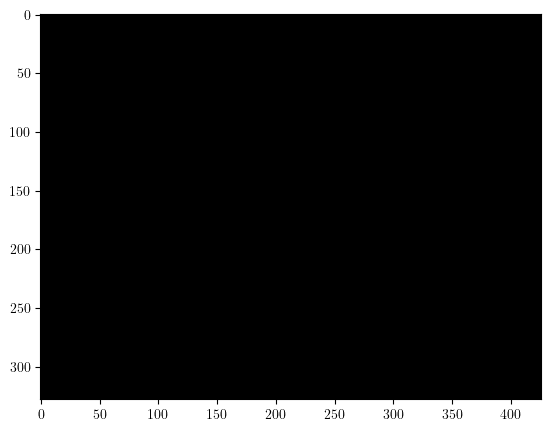

In [350]:
bg = np.zeros_like(frames[0])

plt.figure()
plt.imshow(bg)
plt.show()

# One image: Track Particles

In [351]:
index = 0

In [352]:
im1 = frames[index]

In [353]:
# im1 = normalize8(im1)

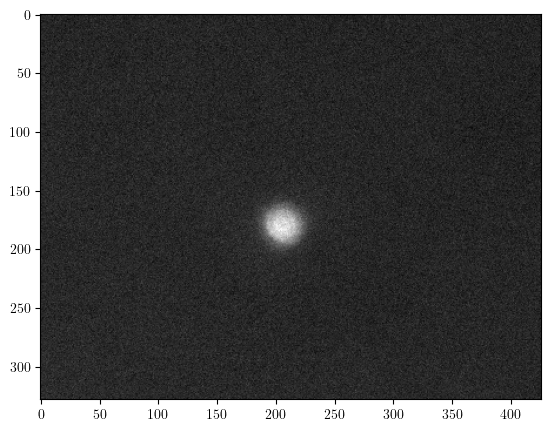

In [354]:
plt.imshow(im1);

In [355]:
# plt.imsave('test.png', im1)

In [356]:
# im1

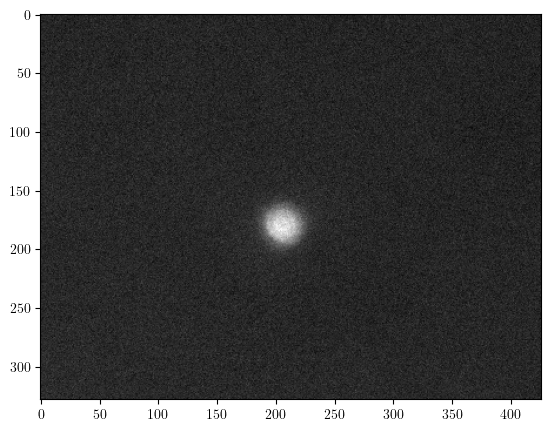

In [357]:
im2 = (im1 - bg) 
# im2 = im1
plt.imshow(im2)

In [358]:
# im2

In [359]:
f2 = tp.locate(im2, 51, invert=False, engine='python')

In [360]:
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep
0,25.124930,245.931139,10630.411573,17.188271,0.154818,39.503058,2054114.0,NaN
1,40.033182,121.415423,12201.693730,17.110377,0.126936,43.378628,2074359.0,NaN
2,40.362290,192.272461,12691.585026,16.665800,0.173975,44.200718,2067096.0,NaN
3,71.107646,55.248398,11689.061485,16.524859,0.070940,53.478599,2074234.0,NaN
4,78.410857,393.473180,9669.216772,17.482332,0.093862,45.375134,2031267.0,NaN


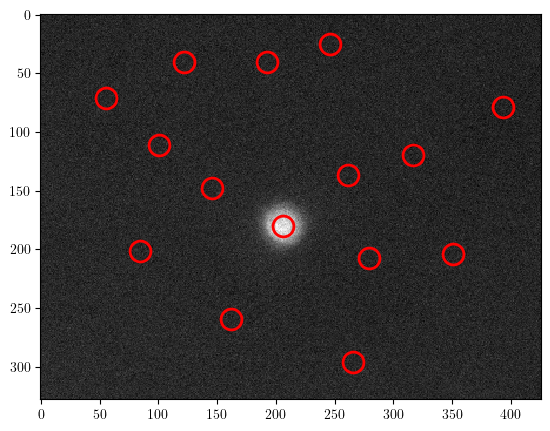

In [361]:
tp.annotate(f2, im2);

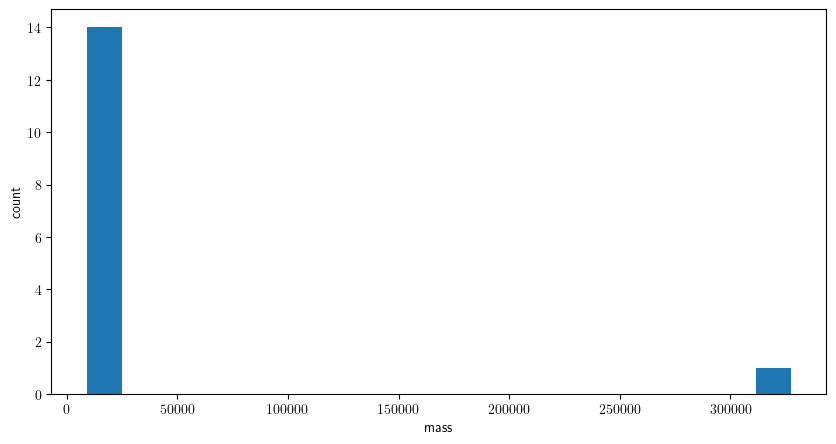

In [362]:
fig, ax = plt.subplots()
ax.hist(f2['mass'], bins=20)

# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

In [363]:
f2 = tp.locate(im2, 121, invert=False, minmass=100_000)
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep
0,179.689154,206.046813,610703.020234,12.784916,0.016794,927.670405,12809202.0,NaN


In [364]:
# f2

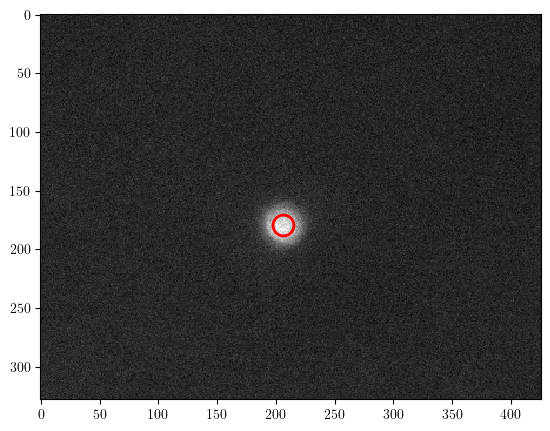

In [365]:
tp.annotate(f2, im2);

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

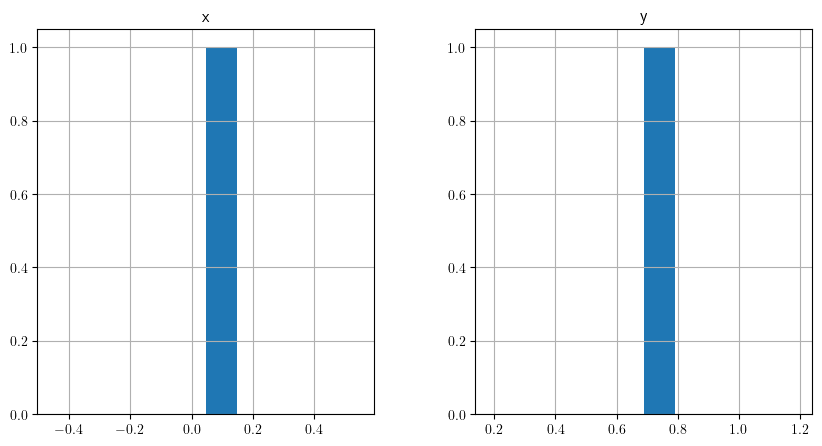

In [366]:
# Check sub-pixel accuracy
tp.subpx_bias(f2)
# Here I changed DataFrame.applymap to DataFrame.map in the source code, because of an update in pandas.
# Source code:
# ~/miniforge3/envs/ista/lib/python3.12/site-packages/trackpy/plots.py

In [367]:
len(f2)

1

# Work on the image

In [368]:
# im3 = np.abs(im2)
# im4 = cv2.GaussianBlur(im3, (3,3), cv2.BORDER_DEFAULT)

In [369]:
# plt.imshow(im4)

In [370]:
# im4

# Track the modified image

In [371]:
# f4 = tp.locate(im4, 51, invert=False, engine='python')

In [372]:
# f4.head()

In [373]:
# tp.annotate(f4, im4)

In [374]:
# fig, ax = plt.subplots()
# ax.hist(f4['mass'], bins=20)

# # Optionally, label the axes.
# ax.set(xlabel='mass', ylabel='count');

In [375]:
# f4b = tp.locate(im4, 15, invert=False, engine='python', minmass=3500, separation=15)

In [376]:
# f4b.head()

In [377]:
# tp.annotate(f4b, im4) 

In [378]:
# f4c = tp.locate(im4, 21, invert=True, engine='python', minmass=200)

In [379]:
# # Keep spherical objects

# index_ecc = f4b['ecc'] < 0.15
# f4c = f4b[index_ecc]

In [380]:
# f4c.head()3

In [381]:
# tp.annotate(f4c, im4)

# Using rings from bright-field microscopy

In [382]:
# R = 9

In [383]:
%%time 
# Locate, without initial guess
# fbf = tp.locate_brightfield_ring(frames[index], 2.0*R+1) # Use a slightly larger radius than expected

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.1 μs


In [384]:
# fbf.head()

In [385]:
# tp.annotate(fbf, frames[index], plot_style={'markersize': 12});

In [386]:
# Locate, with initial guess from no-ring locate function

# To be implemented as it is supposed to speed up the tracking, but not accuracy (according to trackpy doc). 

In [387]:
%%time 

# fbf2 = tp.locate_brightfield_ring(frames[index], 2.0*R+1, previous_coords=f2)

CPU times: user 1e+03 ns, sys: 1 μs, total: 2 μs
Wall time: 3.81 μs


In [388]:
# tp.annotate(fbf2, frames[index], plot_style={'markersize': 12});

In [389]:
# Let's see later, the accuracy seems to be dependent of the normal tracking and reduced

# Delete to clear your mind

In [390]:
del f2, fbf, fbf2

NameError: name 'fbf' is not defined

# Several Images: Tracking and Linking

## Inputs

In [391]:
start = 0
stop = len(frames)

In [392]:
R1 = 51 # radius for spot tracking
minmass = 150_000
separation = 121
invert = False

R2 = 9 # radius for ring tracking

# param_blur = (3,3)

In [393]:
path2vid

'../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/ole011_fps_50_p3_no_shell.tif'

In [394]:
# path2folder = path2vid[:path2vid.find('fps')+len('fps')+1]
# vidname = path2vid[path2vid.find('fps')+len('fps')+1:path2vid.find('.mp4')]
# savename = path2folder + 'trajectories_' + vidname
# savename

# path2folder = '/mnt/share/nfares/group/palacgrp/Nicolas/20260506_coreshell_diffusion/chamber3_water/'
# temp = path2vid[path2vid.find('chamber3_water/')+len('chamber3_water/'):]
# savename = path2folder + 'trajectories_' + temp[:temp.find('.mp4')]
# del temp 

path2folder = '../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/'
vidname = path2vid[path2vid.find(path2folder)+len(path2folder):path2vid.find('.tif')]
savename = path2folder + 'trajectories_' + vidname

print(savename)

../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/trajectories_ole011_fps_50_p3_no_shell


## Create Modified Images

In [395]:
# To be added if necessary and/or included in the tracking loop

## Perform Tracking and Linking

In [396]:
# The following cell corresponds to the tracking of all images
# Automated with the function tp.batch
# I don't use it, because it is easier to do a manual loop if I want to modify each image. 
# See the cells after.

In [397]:
# Track particles in every images 

# # tp.quiet()
# f = tp.batch(frames[start:stop], R1, minmass=minmass, invert=False, separation=separation, processes=1) #, noise_size=1);
# # f['frame'] += start

100%|█████████████████████████████████████████| 500/500 [00:13<00:00, 36.88it/s]


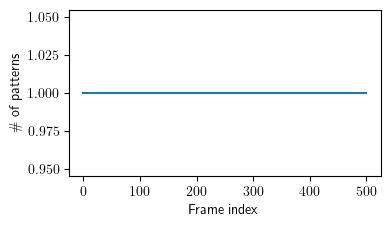

In [398]:
# import time

# Store the number of patterns on each image
count = np.zeros(stop-start)
# count = np.zeros(2)
# Store the tracked patterns in every images
i = int(start)
frame = frames[i]
f = tp.locate(frame, R1, invert=invert, minmass=minmass, separation=separation)
for j in range(len(f)):
    f.at[j, 'frame'] = i
count[i-start] = len(f)
# Loop
for i in tqdm(range(start+1, stop, 1)):
    frame = frames[i]
    ftemp = tp.locate(frame, R1, invert=invert, minmass=minmass, separation=separation)
    # try:
    #     # Artificially correct for 
    #     if ftemp['frame'].iloc[0] != i:
    #         ftemp = ftemp.reset_index(drop=True)
    #         for j in range(len(ftemp)):
    #             ftemp.at[j, 'frame'] = i
    # except:
    ftemp = ftemp.reset_index(drop=True)
    for j in range(len(ftemp)):
        ftemp.at[j, 'frame'] = i
    count[i-start] = len(ftemp)
    f = pd.concat([f, ftemp], ignore_index=True)
    # print(i-start)
    # time.sleep(0.1)
# Plot the nb of patterns per image
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 6/2.54))
ax.plot(np.arange(start, stop, 1), count)
# ax.plot(count)
ax.set(xlabel='Frame index', ylabel=r'\# of patterns')
plt.tight_layout()
plt.show()

In [399]:
f[:10]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,179.958796,206.024355,327455.598712,10.378692,0.030115,699.684561,2796642.0,NaN,0.0
1,180.437808,205.389709,328569.720324,10.449590,0.041652,690.194065,2800378.0,NaN,1.0
2,181.237475,203.682000,327792.471036,10.410197,0.033245,709.072662,2800991.0,NaN,2.0
3,180.073820,204.649607,326767.624351,10.469179,0.031254,684.979766,2800523.0,NaN,3.0
4,180.087121,205.749251,330699.632251,10.444659,0.039384,695.983441,2809649.0,NaN,4.0
5,180.854412,207.541768,334916.134455,10.374266,0.047832,718.962433,2805750.0,NaN,5.0
6,181.094332,208.087712,338668.549233,10.316500,0.056736,716.038120,2813921.0,NaN,6.0
7,180.214464,208.090982,335989.159699,10.365625,0.045542,727.891878,2807840.0,NaN,7.0
8,180.493987,208.132142,332788.885753,10.449488,0.046301,712.327615,2810807.0,NaN,8.0
9,180.137024,207.921110,334168.362880,10.410088,0.047154,713.911875,2807673.0,NaN,9.0


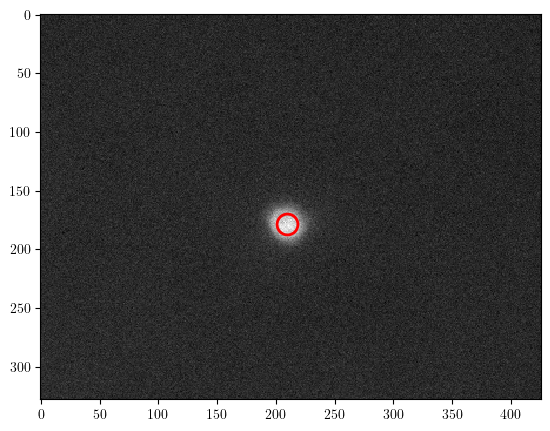

In [400]:
# Check tracking on one image
i = 41
# plt.figure()
# plt.imshow(frames[start+i])
tp.annotate(f[f['frame'] == start+i], frames[start+i])
plt.show()

In [401]:
# Check about duplicates
f[f.duplicated(subset=['frame', 'x', 'y'])]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame


In [402]:
# f[f['frame'] == 19]

In [403]:
# plt.imshow(frames[35] - frames[36])

In [404]:
# Link trajectories

# tp.quiet()
t = tp.link(f, search_range=40, memory=25)

Frame 500: 1 trajectories present.


In [405]:
t.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,179.958796,206.024355,327455.598712,10.378692,0.030115,699.684561,2796642.0,NaN,0,0
1,180.437808,205.389709,328569.720324,10.449590,0.041652,690.194065,2800378.0,NaN,1,0
2,181.237475,203.682000,327792.471036,10.410197,0.033245,709.072662,2800991.0,NaN,2,0
3,180.073820,204.649607,326767.624351,10.469179,0.031254,684.979766,2800523.0,NaN,3,0
4,180.087121,205.749251,330699.632251,10.444659,0.039384,695.983441,2809649.0,NaN,4,0


In [406]:
# Filter too-short trajectories

t1 = tp.filter_stubs(t, threshold=10)

In [407]:
t1.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,179.958796,206.024355,327455.598712,10.378692,0.030115,699.684561,2796642.0,NaN,0,0
1,180.437808,205.389709,328569.720324,10.449590,0.041652,690.194065,2800378.0,NaN,1,0
2,181.237475,203.682000,327792.471036,10.410197,0.033245,709.072662,2800991.0,NaN,2,0
3,180.073820,204.649607,326767.624351,10.469179,0.031254,684.979766,2800523.0,NaN,3,0
4,180.087121,205.749251,330699.632251,10.444659,0.039384,695.983441,2809649.0,NaN,4,0


In [408]:
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())

Before: 1
After: 1


In [409]:
# Filter with conditions on tracked particles
# t2 = t1[((t1['size'] < 30))]
t2 = t1[((t1['ecc'] < 0.9))]

In [410]:
t2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,179.958796,206.024355,327455.598712,10.378692,0.030115,699.684561,2796642.0,NaN,0,0
1,180.437808,205.389709,328569.720324,10.449590,0.041652,690.194065,2800378.0,NaN,1,0
2,181.237475,203.682000,327792.471036,10.410197,0.033245,709.072662,2800991.0,NaN,2,0
3,180.073820,204.649607,326767.624351,10.469179,0.031254,684.979766,2800523.0,NaN,3,0
4,180.087121,205.749251,330699.632251,10.444659,0.039384,695.983441,2809649.0,NaN,4,0


In [411]:
# t2[t2['frame'] == start]

In [412]:
print(t2['particle'].nunique())

1


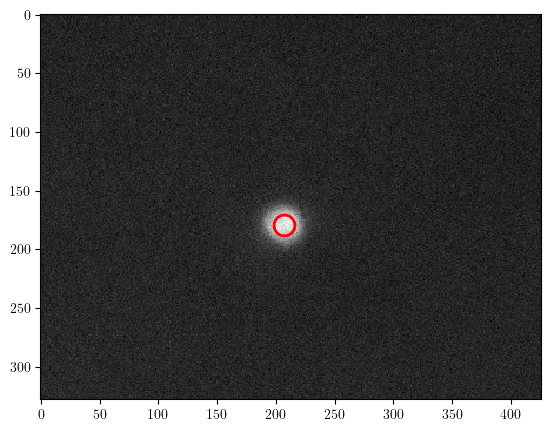

<Axes: >

In [413]:
i = 90
# plt.figure()
# plt.imshow(frames[start+i])
tp.annotate(t2[t2['frame'] == start+i], frames[start+i])

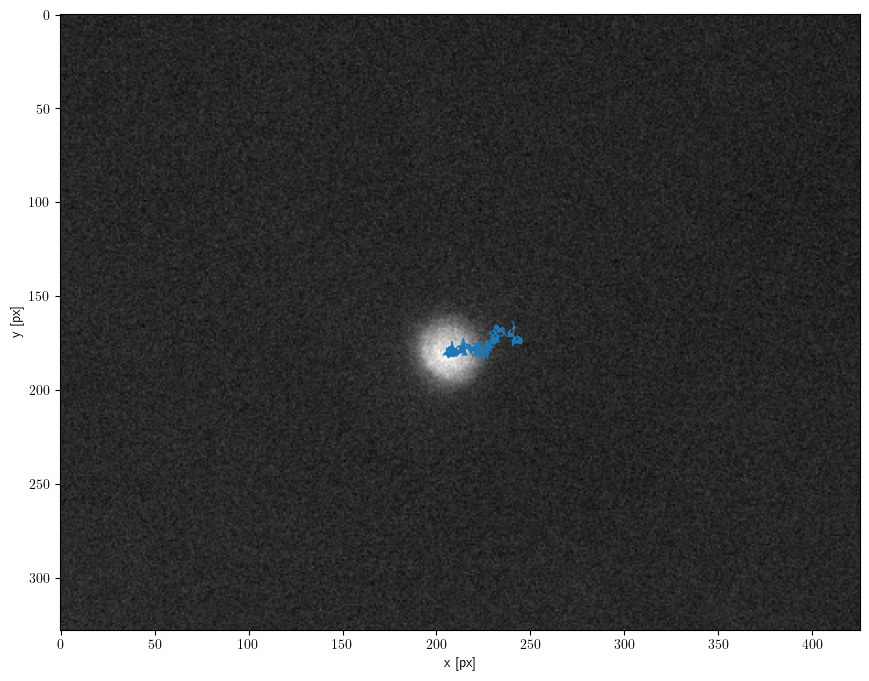

In [414]:
plt.figure(figsize=(15, 8))
plt.imshow(frames[start])
tp.plot_traj(t2);

In [415]:
# p = t2['particle'].unique()
# N = t2['particle'].nunique()

# plt.figure(figsize=(15, 8))
# plt.imshow(frames[start])
# for i in range(len(p)):
#     x = t2[t2['particle'] == p[i]]['x']
#     y = t2[t2['particle'] == p[i]]['y']
#     plt.plot(x, y)
#     plt.annotate(str(p[i]), (x.iloc[0], y.iloc[0]), c='white', size=15)
# plt.show()

In [416]:
# Check the displacement between consecutive frames for a given particle
p_id = 0
traj = t[t['particle'] == p_id].sort_values('frame')
traj['dx'] = traj['x'].diff()
traj['dy'] = traj['y'].diff()
traj['displacement'] = (traj['dx']**2 + traj['dy']**2)**0.5
print(traj['displacement'].max() / (px*1e6))

110.5457830136347


In [417]:
# # Compute drifts

# d = tp.compute_drift(t2)

# d.plot()
# plt.show()

## Checks With MSDs: Last Selection of Tracked Particles 

In [418]:
# Get trajectories

tm = t2.copy() #tp.subtract_drift(t2.copy(), d)

In [419]:
# plt.figure()
# plt.imshow(frames[start])
# tp.plot_traj(tm)
# plt.show()

In [420]:
im = tp.imsd(tm, px*1e6, fps)  # microns per pixel, frames per second

In [421]:
# im

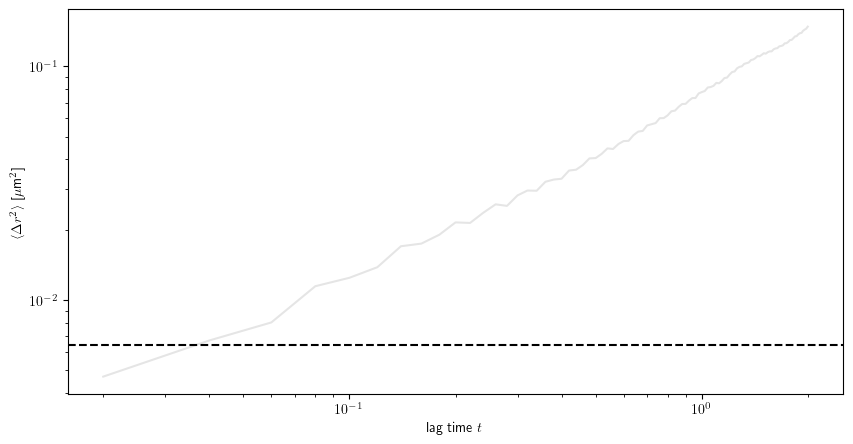

In [422]:
fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')

In [423]:
# Conditions on MSD
# MSD at short time must be below a given value

threshold = 2e-2

# Get MSD at a short time
short_MSD = im.iloc[1]
# Convert to array
array_short_MSD = np.array(short_MSD)
# Get the indexes of the trajectories to exclude, in term of column number
to_exclude = np.where(array_short_MSD > threshold)[0] # Too fast
# to_exclude_2 = np.where(np.isnan(array_late_MSD))[0] # Not defined (NaN)
# to_exclude = np.concatenate((to_exclude_1, to_exclude_2))
# Convert these indexes to particle indexes
to_exclude = im.columns[to_exclude]
# Convert to list
to_exclude = list(to_exclude)
print(to_exclude)

[]


In [424]:
# Exclude
for i in to_exclude:
    tm = tm[tm['particle'] != i]

# Exclude a part of the images
# tm = tm[((tm['x'] < 650))]

# Get particles ids
p = tm['particle'].unique()
N = tm['particle'].nunique()

In [425]:
from scipy.optimize import curve_fit

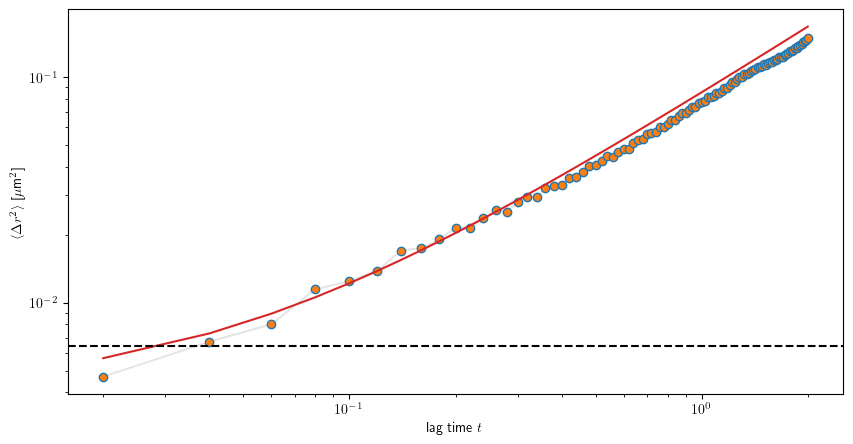

In [426]:
im = tp.imsd(tm, px*1e6, fps)  # microns per pixel, frames per second
em = tp.emsd(tm, px*1e6, fps)  # microns per pixel, frames per second

# Even if I don't like, here it works in micrometers.

lag = em.index

f_diffusion = lambda t, D, d: 4*D*t+(2*d)**2

lagmin = 0
lagmax = 15
popt, _ = curve_fit(f_diffusion, lag[lagmin:lagmax], em[lagmin:lagmax], p0=[1e-2, 0])

fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.plot(em.index, em, 'o', mfc='tab:orange')  
ax.plot(em.index, f_diffusion(em.index, *popt), ls='-', c='tab:red')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

In [427]:
print(popt)

[0.02036755 0.03179341]


In [428]:
print(np.sqrt(np.nanmean(em)) * 1e3)

277.98709401860526


In [429]:
# tm.head()

# Save Final Trajectories

In [430]:
tm['x'] = tm['x'] * px
tm['y'] = tm['y'] * px
tm.to_pickle(savename)

In [91]:
# tm = pd.read_pickle(savename)

# More analysis